**CHATBOT WITH MEMORY**

- Define our state

- We store(append) all messages at the same place rather than having separate fields.



In [14]:
from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph.message import add_messages
from langchain_core.messages import BaseMessage
from langchain_openai import ChatOpenAI
from langgraph.graph import StateGraph
from langchain_core.messages import HumanMessage
# Our in memory checkpointer
from langgraph.checkpoint.memory import MemorySaver


In [15]:
# Create our State Schema
class AgentState(TypedDict):
  # This prevents the chat history from being wipped out by each new node
  # add_messages--> appends new messages
  messages: Annotated[list[BaseMessage], add_messages]

In [16]:
api_key=""

#create llm
llm=ChatOpenAI(
    model="gpt-4o",
    openai_api_key=api_key,
    base_url="https://models.inference.ai.azure.com"
)


In [17]:
# build our node-->  A function that performs a task
# here it passes our question to the LLM
def chatbot(state: AgentState)-> AgentState:
  """Pass user output to the large language model"""
  state['messages']=llm.invoke(state['messages'])
  # the node receives all previous messages and returns the assistants reply
  return state

In [18]:
# Build our graph blueprint
graph=StateGraph(AgentState)

# add our node
graph.add_node('chatbot', chatbot)

# add edges to the end
graph.set_entry_point('chatbot')
graph.set_finish_point('chatbot')

# compile our graph to an executable
#--We add memory firsy
memory=MemorySaver()
app=graph.compile(
    checkpointer=memory
)

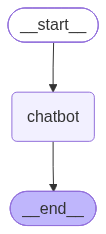

In [19]:
#Now lets visualize the flow of our graph
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

In [22]:
# set our config for the first user
config={
    "configurable":{
        "thread_id":"conversation-1"
    }
}

# Invoke our graph
app.invoke(
    {
        "messages":[
            HumanMessage(content="My Name is Allan, 24 years, aspiring to study Computing Science at TRU 2027 fall. Advance computer hacker")
        ]
    },
    config=config
)

{'messages': [HumanMessage(content='My Name is Allan, 24 years, aspiring to study Computing Science at TRU 2027 fall. Advance computer hacker', additional_kwargs={}, response_metadata={}, id='7fa8dfdb-87fa-4d25-b5b7-725b67159623'),
  AIMessage(content='Hi Allan! It\'s awesome that you\'re planning to study Computing Science at Thompson Rivers University (TRU) in the Fall of 2027. That\'s a great career path, and your interest in computers and technology will definitely serve you well.\n\nOn the subject of being an "advanced computer hacker," I encourage you to approach that interest ethically and responsibly. Hacking skills, when used ethically, can be extremely valuable in areas like cybersecurity, network management, and software development. Ethical hackers, also known as "white-hat hackers," are in high demand to help organizations secure their systems and protect sensitive information from malicious attacks.\n\nIf you\'re aspiring to sharpen your computing skills before starting a

In [24]:
# now check our memory--> Grab only AI message
result=app.invoke(
    {
        "messages":[
            HumanMessage(content="What is my name? what program do I want")
        ]
    },
    config=config
)

# This gets only the last message generated by AI
print(f"AI: {result['messages'][-1].content}")

AI: Your name is **Allan**, and you want to study **Computing Science** at TRU (Thompson Rivers University)! 😊


In [26]:
# Another way to get the last message in a more robust way
from langchain_core.messages import AIMessage
result=app.invoke(
    {
        "messages":[
            HumanMessage(content="How old am I?")
        ]
    },
    config=config
)

# filter AI messages only from  the list
ai_message=[m for m in result['messages'] if isinstance(m, AIMessage)]

# display the last AI message
print(f"AI: {ai_message[-1].content}")

AI: You mentioned that you are **24 years old**. 😊


In [27]:
# we can set a new thread for another user
# set our config for the first user
config={
    "configurable":{
        "thread_id":"conversation-2"
    }
}

# Invoke our graph
app.invoke(
    {
        "messages":[
            HumanMessage(content="My Name is Liam, 14 years, grade 10")
        ]
    },
    config=config
)

{'messages': [HumanMessage(content='My Name is Liam, 14 years, grade 10', additional_kwargs={}, response_metadata={}, id='1e3e5272-4b9a-4780-be94-eec0b03917ea'),
  AIMessage(content="Nice to meet you, Liam! You're in 10th grade at 14 years old — that's impressive! How can I help you today? Are you looking for help with schoolwork, need advice, or just want to chat? 😊", additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 49, 'prompt_tokens': 19, 'total_tokens': 68, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0}, 'latency_checkpoint': {'engine_tbt_ms': 7, 'engine_ttft_ms': 36, 'engine_ttlt_ms': 391, 'pre_inference_ms': 105, 'service_tbt_ms': 7, 'service_ttft_ms': 582, 'service_ttlt_ms': 936, 'total_duration_ms': 835, 'user_visible_ttft_ms': 476}}, 'model_provider': 

In [28]:
# now check our memory--> Grab only AI message
result=app.invoke(
    {
        "messages":[
            HumanMessage(content="What do you know about me?")
        ]
    },
    config=config
)

# This gets only the last message generated by AI
print(f"AI: {result['messages'][-1].content}")

AI: From what you've shared, here's what I know about you so far:

- Your name is **Liam**.
- You're **14 years old**.
- You're in **10th grade**.

That’s about it! I don’t know much else about you unless you choose to share more. If you have hobbies, favorite subjects, or anything you're passionate about, feel free to tell me! Or let me know how I can help you. 😊
